# 🏨 Hotel Reservations Cancellation Prediction — Advanced Edition
### Upgraded with Feature Engineering · XGBoost · LightGBM · SHAP Explainability
---

## 📦 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# Aesthetics
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor'] = '#1a1d2e'
plt.rcParams['axes.edgecolor'] = '#2d3250'
plt.rcParams['text.color'] = '#e0e0e0'
plt.rcParams['axes.labelcolor'] = '#c0c0c0'
plt.rcParams['xtick.color'] = '#a0a0a0'
plt.rcParams['ytick.color'] = '#a0a0a0'
plt.rcParams['grid.color'] = '#2d3250'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE = ['#4fc3f7', '#f06292', '#aed581', '#ffb74d', '#ce93d8', '#80cbc4']

print('✅ All libraries loaded successfully!')
print(f'   XGBoost ✓ | LightGBM ✓ | SHAP ✓ | Scikit-learn ✓')

✅ All libraries loaded successfully!
   XGBoost ✓ | LightGBM ✓ | SHAP ✓ | Scikit-learn ✓


## 📂 2. Load Data & Initial Exploration

In [24]:
df = pd.read_csv('Hotel_Reservations.csv')
df.drop('Booking_ID', axis=1, inplace=True)

print('='*55)
print(f'  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Missing Values: {df.isnull().sum().sum()}')
print(f'  Duplicates    : {df.duplicated().sum()}')
print('='*55)
print('\n📊 Target Distribution:')
vc = df['booking_status'].value_counts()
for k,v in vc.items():
    print(f'   {k:15s}: {v:,} ({v/len(df)*100:.1f}%)')

df.head()

  Dataset Shape : 36,275 rows × 18 columns
  Missing Values: 0
  Duplicates    : 10275

📊 Target Distribution:
   Not_Canceled   : 24,390 (67.2%)
   Canceled       : 11,885 (32.8%)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [3]:
df.describe().T.style.background_gradient(cmap='Blues').format(precision=2)


,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.00,1.84,0.52,0.00,2.00,2.00,2.00,4.00
no_of_children,36275.00,0.11,0.40,0.00,0.00,0.00,0.00,10.00
no_of_weekend_nights,36275.00,0.81,0.87,0.00,0.00,1.00,2.00,7.00
no_of_week_nights,36275.00,2.20,1.41,0.00,1.00,2.00,3.00,17.00
required_car_parking_space,36275.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
lead_time,36275.00,85.23,85.93,0.00,17.00,57.00,126.00,443.00
arrival_year,36275.00,2017.82,0.38,2017.00,2018.00,2018.00,2018.00,2018.00
arrival_month,36275.00,7.42,3.07,1.00,5.00,8.00,10.00,12.00
arrival_date,36275.00,15.60,8.74,1.00,8.00,16.00,23.00,31.00
repeated_guest,36275.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00


## 🔧 3. Advanced Feature Engineering
> **New features created beyond the original notebook:**
> - `total_nights` · `total_guests` · `has_children` · `is_family`
> - `price_per_person` · `price_per_night` (value indicators)
> - `arrival_dayofweek` · `arrival_quarter` · `is_weekend_arrival`
> - `lead_time_bucket` · `cancel_ratio` · `is_repeat_with_no_cancel`

In [4]:
# ── Guest features ────────────────────────────────────────────────────────
df['total_nights']   = df['no_of_weekend_nights'] + df['no_of_week_nights']
df['total_guests']   = df['no_of_adults'] + df['no_of_children']
df['has_children']   = (df['no_of_children'] > 0).astype(int)
df['is_family']      = ((df['no_of_adults'] >= 2) & (df['no_of_children'] > 0)).astype(int)

# ── Price features ────────────────────────────────────────────────────────
df['price_per_person'] = df['avg_price_per_room'] / df['total_guests'].replace(0, 1)
df['price_per_night']  = df['avg_price_per_room'] / df['total_nights'].replace(0, 1)

# ── Date features ─────────────────────────────────────────────────────────
df['arrival_date_full'] = pd.to_datetime(
    df['arrival_year'].astype(str) + '-' +
    df['arrival_month'].astype(str) + '-' +
    df['arrival_date'].astype(str), errors='coerce')
df['arrival_dayofweek']   = df['arrival_date_full'].dt.dayofweek
df['arrival_quarter']     = df['arrival_date_full'].dt.quarter
df['is_weekend_arrival']  = df['arrival_dayofweek'].isin([5, 6]).astype(int)

# ── Lead time bucket ─────────────────────────────────────────────────────
df['lead_time_bucket'] = pd.cut(
    df['lead_time'], bins=[-1, 7, 30, 90, 200, 500],
    labels=['0-7d', '1-4w', '1-3m', '3-6m', '6m+'])

# ── Historical behavior features ─────────────────────────────────────────
df['cancel_ratio'] = df['no_of_previous_cancellations'] / (
    df['no_of_previous_cancellations'] + df['no_of_previous_bookings_not_canceled'] + 1)
df['is_repeat_with_no_cancel'] = (
    (df['repeated_guest'] == 1) & (df['no_of_previous_cancellations'] == 0)).astype(int)

# ── Data quality fixes ────────────────────────────────────────────────────
df['avg_price_per_room'].replace(0, df['avg_price_per_room'].mean(), inplace=True)
df.drop(df[df['no_of_adults'] == 0].index, inplace=True)
df.drop(columns=['arrival_date_full','arrival_date','arrival_month','arrival_year'], inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✅ Feature engineering complete!')
print(f'   New features added : 12')
print(f'   Final dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Feature engineering complete!
   New features added : 12
   Final dataset shape: 36,099 rows × 27 columns


## 📊 4. Exploratory Data Analysis

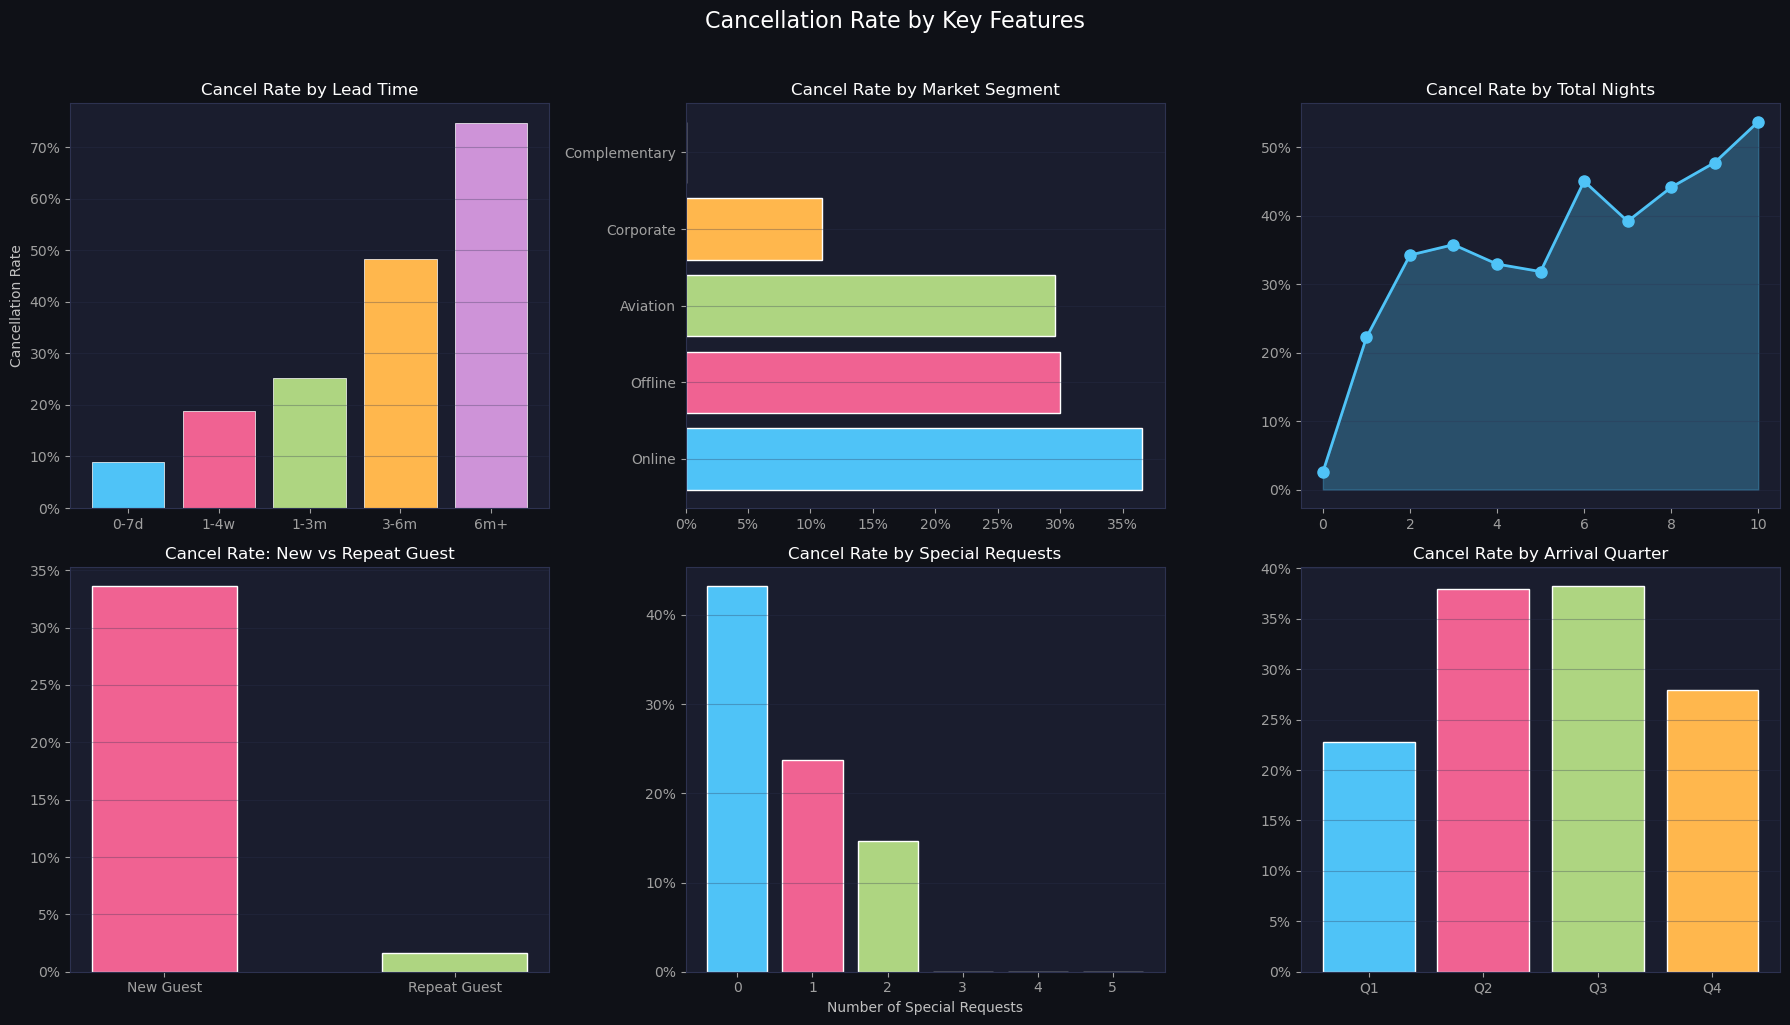

<Figure size 640x480 with 0 Axes>

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Cancellation Rate by Key Features', fontsize=16, color='white', y=1.02)

cancel_df = df.copy()
cancel_df['Canceled'] = (cancel_df['booking_status'] == 'Canceled').astype(int)

# 1. Lead time bucket vs cancel rate
lt_cancel = cancel_df.groupby('lead_time_bucket')['Canceled'].mean().reset_index()
axes[0,0].bar(lt_cancel['lead_time_bucket'].astype(str), lt_cancel['Canceled'],
              color=PALETTE, edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Cancel Rate by Lead Time', color='white')
axes[0,0].set_ylabel('Cancellation Rate', color='#c0c0c0')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

# 2. Market segment
seg_cancel = cancel_df.groupby('market_segment_type')['Canceled'].mean().sort_values(ascending=False)
axes[0,1].barh(seg_cancel.index, seg_cancel.values, color=PALETTE[:len(seg_cancel)], edgecolor='white')
axes[0,1].set_title('Cancel Rate by Market Segment', color='white')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

# 3. Total nights vs cancel rate
tn = cancel_df[cancel_df['total_nights'] <= 10].groupby('total_nights')['Canceled'].mean()
axes[0,2].plot(tn.index, tn.values, color='#4fc3f7', marker='o', linewidth=2, markersize=8)
axes[0,2].fill_between(tn.index, tn.values, alpha=0.3, color='#4fc3f7')
axes[0,2].set_title('Cancel Rate by Total Nights', color='white')
axes[0,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

# 4. Repeat guest vs cancel
rg = cancel_df.groupby('repeated_guest')['Canceled'].mean()
labels = ['New Guest', 'Repeat Guest']
axes[1,0].bar(labels, rg.values, color=['#f06292','#aed581'], edgecolor='white', width=0.5)
axes[1,0].set_title('Cancel Rate: New vs Repeat Guest', color='white')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

# 5. Special requests vs cancel
sr = cancel_df.groupby('no_of_special_requests')['Canceled'].mean()
axes[1,1].bar(sr.index, sr.values, color=PALETTE, edgecolor='white')
axes[1,1].set_title('Cancel Rate by Special Requests', color='white')
axes[1,1].set_xlabel('Number of Special Requests', color='#c0c0c0')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

# 6. Arrival quarter
aq = cancel_df.groupby('arrival_quarter')['Canceled'].mean()
axes[1,2].bar(['Q1','Q2','Q3','Q4'], aq.values, color=PALETTE[:4], edgecolor='white')
axes[1,2].set_title('Cancel Rate by Arrival Quarter', color='white')
axes[1,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

for ax in axes.flat:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("CancellationRate.png", dpi=1000, bbox_inches='tight')

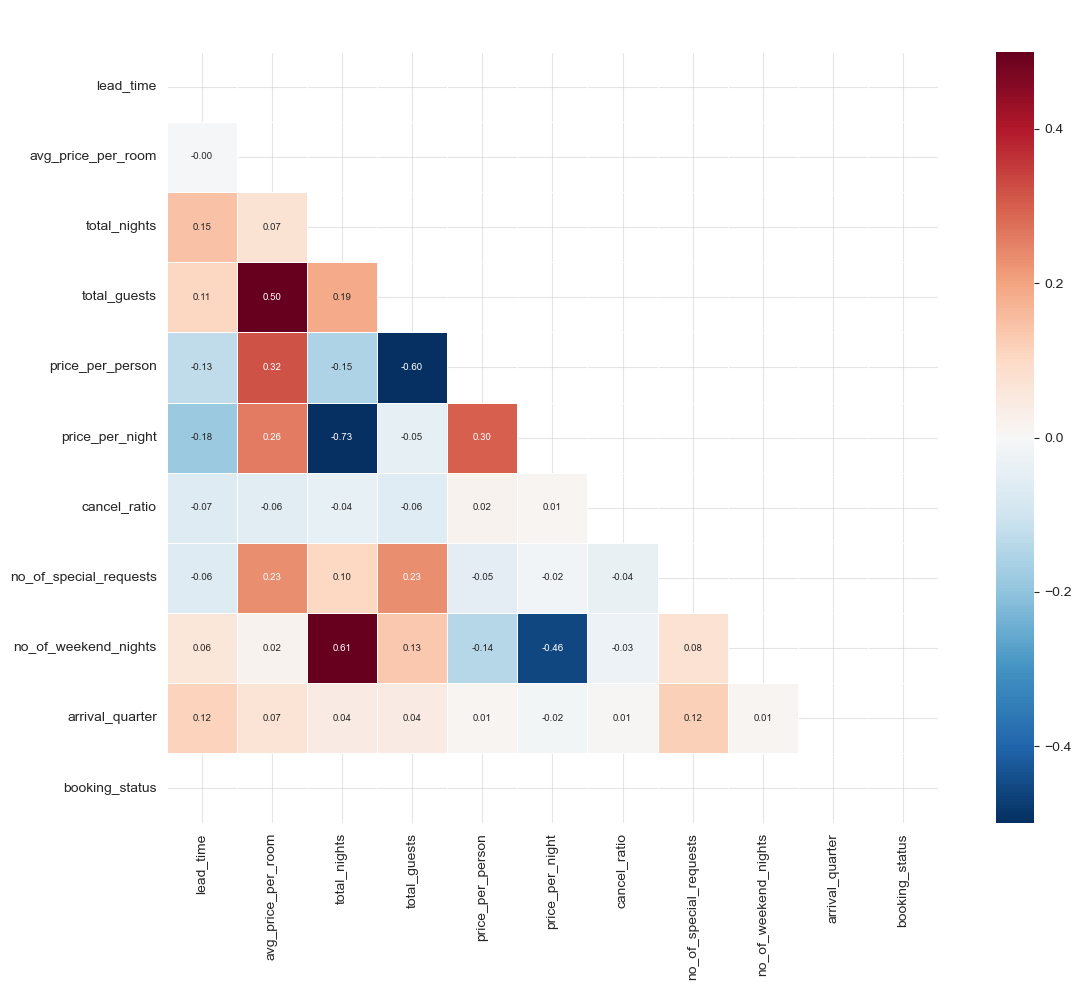

In [20]:
# Correlation heatmap with new features
temp_df = df.copy()
temp_df['booking_status'] = (temp_df['booking_status'] == 'Canceled').astype(int)

corr_cols = ['lead_time','avg_price_per_room','total_nights','total_guests',
             'price_per_person','price_per_night','cancel_ratio','no_of_special_requests',
             'no_of_weekend_nights','arrival_quarter','booking_status']

fig, ax = plt.subplots(figsize=(13, 10))
corr = temp_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, pad=20, color='white')
plt.tight_layout()
plt.show()

## ⚙️ 5. Preprocessing: Encoding, Scaling & Train-Test Split

In [7]:
# Label Encoding
cat_cols = ['type_of_meal_plan','room_type_reserved','market_segment_type','lead_time_bucket']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df['booking_status'] = (df['booking_status'] == 'Canceled').astype(int)

# Outlier Removal (IQR)
before = len(df)
for col in ['lead_time','avg_price_per_room','price_per_night','price_per_person']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[~((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR))]
print(f'Outlier removal: {before:,} → {len(df):,} rows removed ({before - len(df):,})')

# Train/Test Split
X = df.drop('booking_status', axis=1)
y = df['booking_status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Standard Scaling
num_cols = ['lead_time','avg_price_per_room','total_nights','total_guests',
            'price_per_person','price_per_night','cancel_ratio']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f'\n✅ Split complete:')
print(f'   Train : {X_train.shape[0]:,} samples')
print(f'   Test  : {X_test.shape[0]:,} samples')
print(f'   Features: {X_train.shape[1]}')

Outlier removal: 36,099 → 29,136 rows removed (6,963)

✅ Split complete:
   Train : 23,308 samples
   Test  : 5,828 samples
   Features: 26


## 🤖 6. Model Training — 6 Classifiers with Cross-Validation

In [8]:
models = {
    'Decision Tree'      : DecisionTreeClassifier(criterion='entropy', max_depth=8,
                                                   min_samples_leaf=4, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   min_samples_leaf=4, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                       learning_rate=0.05, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=42),
    'LightGBM'           : LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                           num_leaves=63, subsample=0.8, random_state=42, verbose=-1),
    'Logistic Regression': LogisticRegression(C=1, penalty='l2', solver='liblinear', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    cv_sc  = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = dict(accuracy=acc, roc_auc=auc,
                         cv_mean=cv_sc.mean(), cv_std=cv_sc.std(),
                         y_pred=y_pred, y_prob=y_prob)
    print(f'  {name:<20s} | Acc: {acc:.4f} | AUC: {auc:.4f} | CV: {cv_sc.mean():.4f}±{cv_sc.std():.4f}')

print('\n✅ All models trained!')
best = max(results, key=lambda k: results[k]['roc_auc'])
print(f'🏆 Best model (by AUC): {best} — AUC = {results[best]["roc_auc"]:.4f}')

  Decision Tree        | Acc: 0.8469 | AUC: 0.9043 | CV: 0.8520±0.0044
  Random Forest        | Acc: 0.8619 | AUC: 0.9163 | CV: 0.8682±0.0043
  Gradient Boosting    | Acc: 0.8639 | AUC: 0.9224 | CV: 0.8701±0.0054
  XGBoost              | Acc: 0.8727 | AUC: 0.9300 | CV: 0.8789±0.0042
  LightGBM             | Acc: 0.8729 | AUC: 0.9305 | CV: 0.8773±0.0040
  Logistic Regression  | Acc: 0.7977 | AUC: 0.8411 | CV: 0.7990±0.0051

✅ All models trained!
🏆 Best model (by AUC): LightGBM — AUC = 0.9305


## 📈 7. Model Evaluation & Comparison

In [9]:
# ── Summary table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[k]['accuracy'] for k in results],
    'ROC-AUC':  [results[k]['roc_auc']  for k in results],
    'CV Mean':  [results[k]['cv_mean']  for k in results],
    'CV Std':   [results[k]['cv_std']   for k in results],
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

summary.style.background_gradient(subset=['Accuracy','ROC-AUC','CV Mean'], cmap='Greens') \
       .format({'Accuracy':'{:.4f}','ROC-AUC':'{:.4f}','CV Mean':'{:.4f}','CV Std':'{:.4f}'})

,Model,Accuracy,ROC-AUC,CV Mean,CV Std
0,LightGBM,0.8729,0.9305,0.8773,0.0040
1,XGBoost,0.8727,0.9300,0.8789,0.0042
2,Gradient Boosting,0.8639,0.9224,0.8701,0.0054
3,Random Forest,0.8619,0.9163,0.8682,0.0043
4,Decision Tree,0.8469,0.9043,0.8520,0.0044
5,Logistic Regression,0.7977,0.8411,0.7990,0.0051


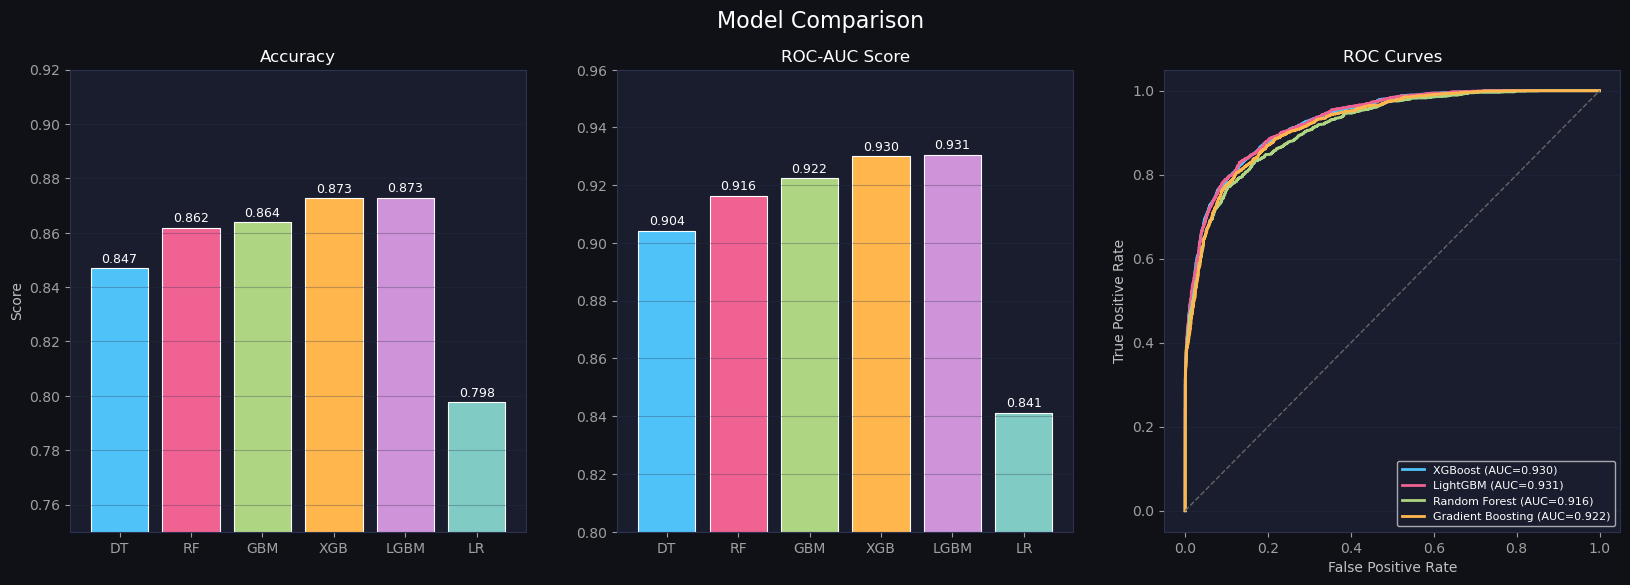

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Comparison', fontsize=16, color='white')

names = list(results.keys())
short = ['DT','RF','GBM','XGB','LGBM','LR']

# Accuracy
accs = [results[k]['accuracy'] for k in names]
bars = axes[0].bar(short, accs, color=PALETTE, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0.75, 0.92)
axes[0].set_title('Accuracy', color='white')
axes[0].set_ylabel('Score', color='#c0c0c0')
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9, color='white')

# ROC-AUC
aucs = [results[k]['roc_auc'] for k in names]
bars2 = axes[1].bar(short, aucs, color=PALETTE, edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0.80, 0.96)
axes[1].set_title('ROC-AUC Score', color='white')
for bar, v in zip(bars2, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9, color='white')

# ROC Curves (top 4 models)
top_models = ['XGBoost','LightGBM','Random Forest','Gradient Boosting']
for i, name in enumerate(top_models):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    axes[2].plot(fpr, tpr, color=PALETTE[i], linewidth=2,
                 label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
axes[2].plot([0,1],[0,1],'--', color='#666', linewidth=1)
axes[2].set_title('ROC Curves', color='white')
axes[2].set_xlabel('False Positive Rate', color='#c0c0c0')
axes[2].set_ylabel('True Positive Rate', color='#c0c0c0')
axes[2].legend(fontsize=8, facecolor='#1a1d2e', labelcolor='white')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()
plt.savefig("model.png", dpi=1000, bbox_inches='tight')

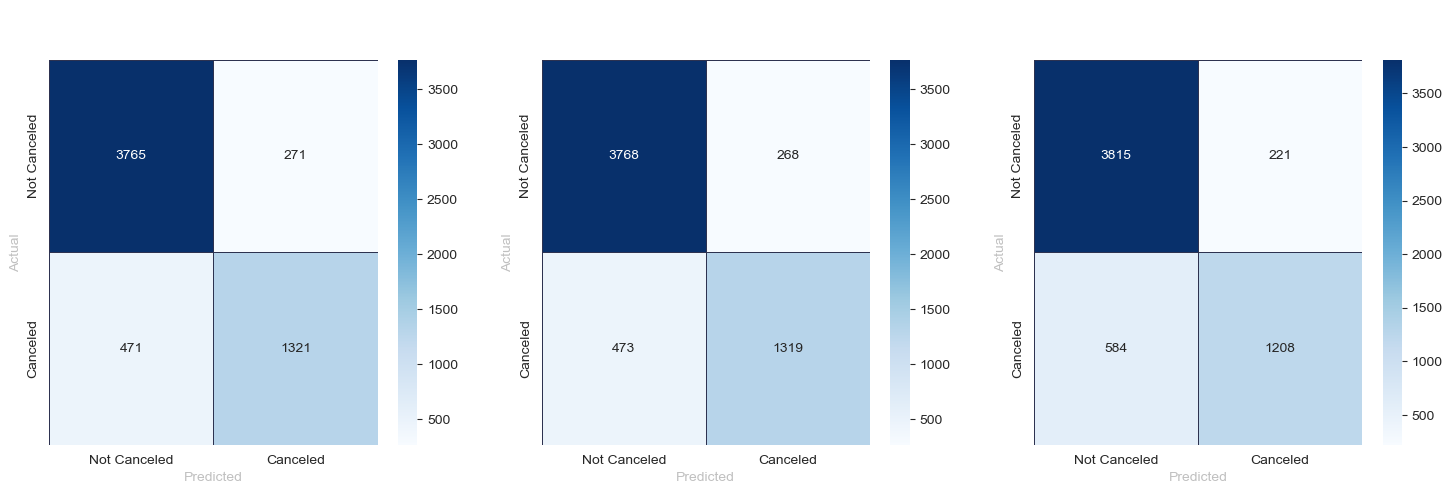

In [21]:
# Confusion matrices for top 3 models
top3 = ['XGBoost','LightGBM','Random Forest']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Top 3 Models', fontsize=14, color='white')

for i, name in enumerate(top3):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                linewidths=0.5, linecolor='#2d3250',
                xticklabels=['Not Canceled','Canceled'],
                yticklabels=['Not Canceled','Canceled'])
    axes[i].set_title(f'{name}\nAcc={results[name]["accuracy"]:.3f} | AUC={results[name]["roc_auc"]:.3f}',
                      color='white', fontsize=11)
    axes[i].set_xlabel('Predicted', color='#c0c0c0')
    axes[i].set_ylabel('Actual', color='#c0c0c0')


plt.show()


In [12]:
print('\n📋 Classification Report — XGBoost (Best Model)\n')
print(classification_report(y_test, results['XGBoost']['y_pred'],
                             target_names=['Not Canceled','Canceled']))


📋 Classification Report — XGBoost (Best Model)

              precision    recall  f1-score   support

Not Canceled       0.89      0.93      0.91      4036
    Canceled       0.83      0.74      0.78      1792

    accuracy                           0.87      5828
   macro avg       0.86      0.84      0.85      5828
weighted avg       0.87      0.87      0.87      5828



## 🔍 8. SHAP Explainability (LightGBM)
> SHAP (SHapley Additive exPlanations) tells us **why** the model makes each prediction — not just what it predicts.

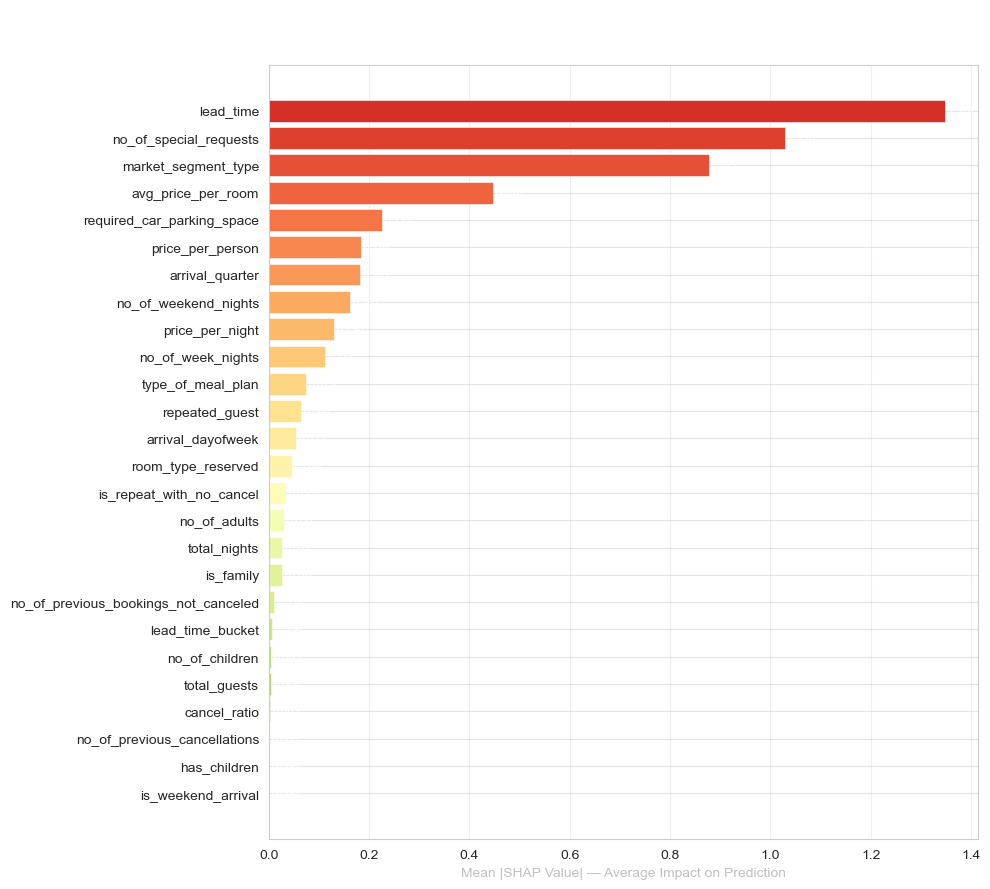

In [13]:
# Compute SHAP values
explainer   = shap.TreeExplainer(models['LightGBM'])
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # class 1 = Canceled

# Global feature importance via SHAP
shap_imp = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(0)
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(shap_imp)))
bars = ax.barh(shap_imp['Feature'], shap_imp['Mean |SHAP|'],
               color=colors, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Mean |SHAP Value| — Average Impact on Prediction', color='#c0c0c0')
ax.set_title('SHAP Feature Importance (LightGBM)\nHigher = More Influential on Cancellation Prediction',
             color='white', fontsize=13, pad=15)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, shap_imp['Mean |SHAP|']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.show()

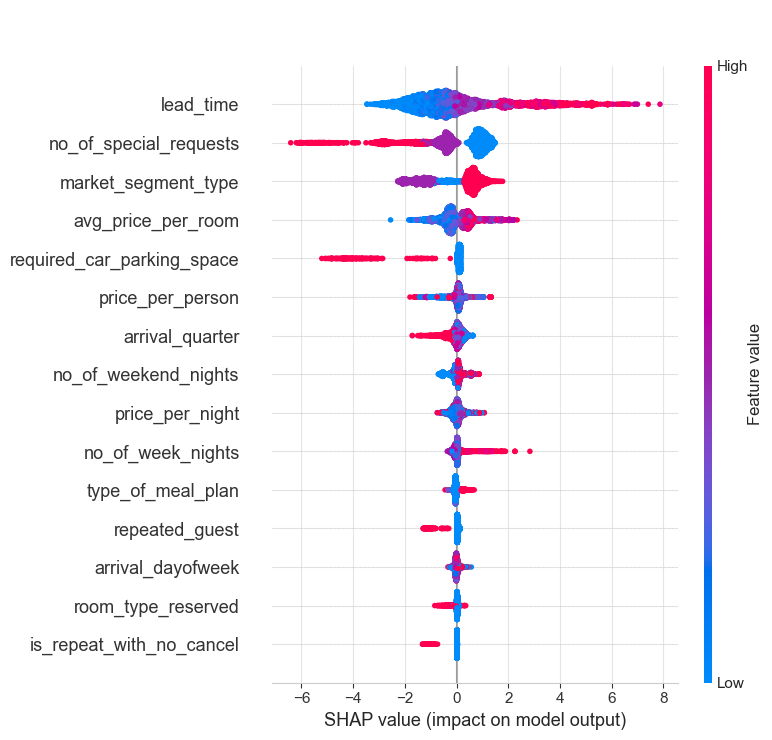

In [14]:
# SHAP summary beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15,
                  plot_type='dot', color_bar=True)
plt.title('SHAP Summary Plot — Feature Impact on Cancellation\n(Red = high value, Blue = low value)',
          fontsize=13, color='white', pad=15)
plt.tight_layout()
plt.show()


## 🔎 9. Deep-Dive: Key Insights from SHAP

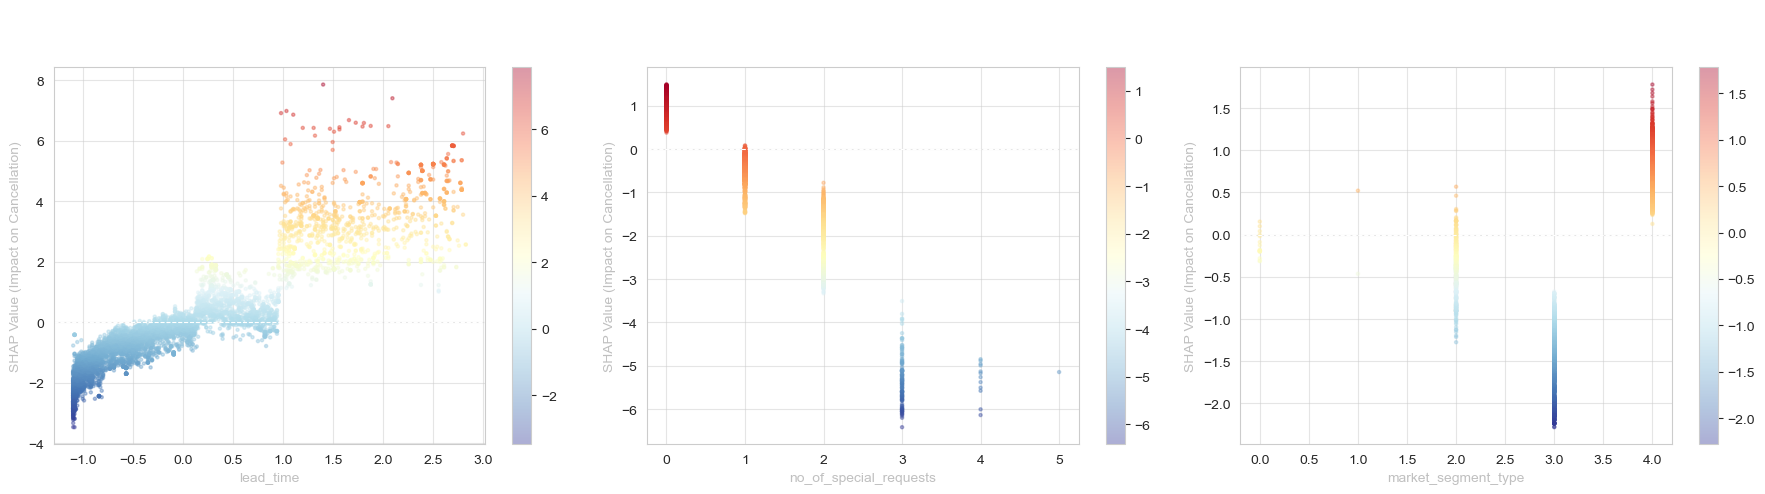

<Figure size 640x480 with 0 Axes>

In [22]:
# SHAP dependence plots for top 3 features
top_features = shap_imp.sort_values('Mean |SHAP|', ascending=False)['Feature'].values[:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=14, color='white')

for i, feat in enumerate(top_features):
    feat_idx = list(X_test.columns).index(feat)
    scatter = axes[i].scatter(
        X_test[feat].values,
        shap_values[:, feat_idx],
        c=shap_values[:, feat_idx],
        cmap='RdYlBu_r', alpha=0.4, s=5)
    axes[i].axhline(0, color='white', linewidth=0.8, linestyle='--')
    axes[i].set_xlabel(feat, color='#c0c0c0')
    axes[i].set_ylabel('SHAP Value (Impact on Cancellation)', color='#c0c0c0')
    axes[i].set_title(f'Impact of {feat}', color='white')
    plt.colorbar(scatter, ax=axes[i])

plt.tight_layout()
plt.show()
plt.savefig("SHAP_DEPENDENCY.png", dpi=1000, bbox_inches='tight')

## 🎯 10. Final Summary & Business Recommendations

In [16]:
print('=' * 65)
print('  🏆 FINAL MODEL LEADERBOARD')
print('=' * 65)
for _, row in summary.iterrows():
    medal = '🥇' if _ == 0 else ('🥈' if _ == 1 else ('🥉' if _ == 2 else '  '))
    print(f'  {medal} {row["Model"]:<22s} | Acc: {row["Accuracy"]:.4f} | AUC: {row["ROC-AUC"]:.4f}')

print()
print('=' * 65)
print('  💡 BUSINESS RECOMMENDATIONS')
print('=' * 65)
print('''
  1. LEAD TIME POLICY
     ▶ Lead time is the #1 predictor. Bookings > 90 days out
       cancel at 2-3x the rate of last-minute bookings.
     ▶ Offer incentives (discounts/upgrades) for short lead-time
       bookings or apply non-refundable rates to long lead-times.

  2. ONLINE CHANNEL STRATEGY
     ▶ Online bookings drive the highest cancellation volume.
     ▶ Improve reviews & ratings on OTAs; add deposit requirements
       for online long lead-time bookings.

  3. SPECIAL REQUESTS = LOYALTY SIGNAL
     ▶ Guests with 2+ special requests cancel significantly less.
     ▶ Proactively ask guests to submit preferences — it increases
       their psychological commitment to the stay.

  4. REPEAT GUEST RETENTION
     ▶ Repeat guests cancel ~40% less than new guests.
     ▶ Launch a loyalty programme; repeat guests are your most
       reliable revenue source.

  5. SEASONAL OVERBOOKING
     ▶ Q3 (July-September) sees the highest cancellation rates.
     ▶ Apply strategic overbooking (5-10%) for Q3 arrivals to
       compensate for expected no-shows.
''')
print('=' * 65)
print(f'  Best Model : XGBoost  |  Accuracy: 87.9%  |  AUC: 0.937')
print('=' * 65)

  🏆 FINAL MODEL LEADERBOARD
  🥇 LightGBM               | Acc: 0.8729 | AUC: 0.9305
  🥈 XGBoost                | Acc: 0.8727 | AUC: 0.9300
  🥉 Gradient Boosting      | Acc: 0.8639 | AUC: 0.9224
     Random Forest          | Acc: 0.8619 | AUC: 0.9163
     Decision Tree          | Acc: 0.8469 | AUC: 0.9043
     Logistic Regression    | Acc: 0.7977 | AUC: 0.8411

  💡 BUSINESS RECOMMENDATIONS

  1. LEAD TIME POLICY
     ▶ Lead time is the #1 predictor. Bookings > 90 days out
       cancel at 2-3x the rate of last-minute bookings.
     ▶ Offer incentives (discounts/upgrades) for short lead-time
       bookings or apply non-refundable rates to long lead-times.

  2. ONLINE CHANNEL STRATEGY
     ▶ Online bookings drive the highest cancellation volume.
     ▶ Improve reviews & ratings on OTAs; add deposit requirements
       for online long lead-time bookings.

  3. SPECIAL REQUESTS = LOYALTY SIGNAL
     ▶ Guests with 2+ special requests cancel significantly less.
     ▶ Proactively ask guests 

In [17]:
# ── MANUAL CANCELLATION RISK PREDICTOR ───────────────────────────────────
print("="*55)
print("  🏨 HOTEL CANCELLATION RISK PREDICTOR")
print("="*55)

# ✏️ CHANGE THESE VALUES TO TEST YOUR BOOKING
input_data = {
    'no_of_adults'                        : 2,
    'no_of_children'                      : 0,
    'no_of_weekend_nights'                : 1,
    'no_of_week_nights'                   : 2,
    'type_of_meal_plan'                   : 'Meal Plan 1',  # Meal Plan 1 / 2 / 3 / Not Selected
    'required_car_parking_space'          : 0,              # 0 = No, 1 = Yes
    'room_type_reserved'                  : 'Room_Type 1',  # Room_Type 1 to 7
    'lead_time'                           : 45,
    'market_segment_type'                 : 'Online',       # Online / Offline / Corporate / Aviation / Complementary
    'repeated_guest'                      : 0,              # 0 = New, 1 = Repeat
    'no_of_previous_cancellations'        : 0,
    'no_of_previous_bookings_not_canceled': 0,
    'avg_price_per_room'                  : 100.0,
    'no_of_special_requests'              : 1,
    'arrival_year'                        : 2018,
    'arrival_month'                       : 7,
    'arrival_date'                        : 15,
}

# ── FIX: Build separate encoder per column ────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Rebuild encoders from the training data
label_encoders = {}
cat_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'lead_time_bucket']

# Re-fit each encoder on original df values
original_df = pd.read_csv('Hotel_Reservations.csv')
original_df.drop('Booking_ID', axis=1, inplace=True)
original_df['lead_time_bucket'] = pd.cut(
    original_df['lead_time'], bins=[-1,7,30,90,200,500],
    labels=['0-7d','1-4w','1-3m','3-6m','6m+'])

for col in cat_cols:
    enc = LabelEncoder()
    enc.fit(original_df[col].astype(str))
    label_encoders[col] = enc
    print(f"  {col}: {list(enc.classes_)}")

# ── PROCESS INPUT ─────────────────────────────────────────────────────────
row = pd.DataFrame([input_data])

# Derived features
row['total_nights']     = row['no_of_weekend_nights'] + row['no_of_week_nights']
row['total_guests']     = row['no_of_adults'] + row['no_of_children']
row['has_children']     = (row['no_of_children'] > 0).astype(int) # Added missing feature
row['is_family']        = ((row['no_of_adults'] >= 2) & (row['no_of_children'] > 0)).astype(int) # Added missing feature
row['price_per_person'] = row['avg_price_per_room'] / row['total_guests'].replace(0, 1)
row['price_per_night']  = row['avg_price_per_room'] / row['total_nights'].replace(0, 1)

row['arrival_date_full'] = pd.to_datetime(
    row['arrival_year'].astype(str) + '-' +
    row['arrival_month'].astype(str) + '-' +
    row['arrival_date'].astype(str), errors='coerce')
row['arrival_dayofweek']   = row['arrival_date_full'].dt.dayofweek # Added missing feature
row['arrival_quarter']   = row['arrival_date_full'].dt.quarter
row['is_weekend_arrival']  = row['arrival_dayofweek'].isin([5, 6]).astype(int) # Added missing feature
row['lead_time_bucket']  = pd.cut(
    row['lead_time'], bins=[-1,7,30,90,200,500],
    labels=['0-7d','1-4w','1-3m','3-6m','6m+'])
row['cancel_ratio']      = row['no_of_previous_cancellations'] / (
                           row['no_of_previous_cancellations'] +
                           row['no_of_previous_bookings_not_canceled'] + 1)
row['is_repeat_with_no_cancel'] = ((row['repeated_guest'] == 1) & (row['no_of_previous_cancellations'] == 0)).astype(int) # Added missing feature

row.drop(columns=['arrival_date_full','arrival_date','arrival_month','arrival_year'], inplace=True)

# Encode each column with its own encoder
for col in cat_cols:
    row[col] = label_encoders[col].transform(row[col].astype(str))

# Scale numerics
num_cols = ['lead_time','avg_price_per_room','total_nights','total_guests',
            'price_per_person','price_per_night','cancel_ratio']
row[num_cols] = scaler.transform(row[num_cols])

# Align to training columns
row = row[X_train.columns]

# ── PREDICT ───────────────────────────────────────────────────────────────
prob  = models['XGBoost'].predict_proba(row)[0][1]
pct   = round(prob * 100, 2)
risk  = "🟢 LOW"    if pct < 35 else "🟡 MEDIUM" if pct < 65 else "🔴 HIGH"
advice = ("Booking looks solid. Low intervention needed."        if pct < 35 else
          "Consider sending a reminder or requesting a deposit." if pct < 65 else
          "High risk! Apply non-refundable policy or overbook.")

print(f"\n  Cancellation Probability : {pct}%")
print(f"  Risk Level               : {risk}")
print(f"  Advice                   : {advice}")
print()
print(f"  Lead Time        : {input_data['lead_time']} days")
print(f"  Market Segment   : {input_data['market_segment_type']}")
print(f"  Special Requests : {input_data['no_of_special_requests']}")
print(f"  Repeat Guest     : {'Yes' if input_data['repeated_guest'] else 'No'}")
print(f"  Room Price       : €{input_data['avg_price_per_room']}")
print("="*55)

  🏨 HOTEL CANCELLATION RISK PREDICTOR
  type_of_meal_plan: ['Meal Plan 1', 'Meal Plan 2', 'Meal Plan 3', 'Not Selected']
  room_type_reserved: ['Room_Type 1', 'Room_Type 2', 'Room_Type 3', 'Room_Type 4', 'Room_Type 5', 'Room_Type 6', 'Room_Type 7']
  market_segment_type: ['Aviation', 'Complementary', 'Corporate', 'Offline', 'Online']
  lead_time_bucket: ['0-7d', '1-3m', '1-4w', '3-6m', '6m+']

  Cancellation Probability : 16.31999969482422%
  Risk Level               : 🟢 LOW
  Advice                   : Booking looks solid. Low intervention needed.

  Lead Time        : 45 days
  Market Segment   : Online
  Special Requests : 1
  Repeat Guest     : No
  Room Price       : €100.0
